# Portfolio Optimisation

## Objective

This notebook investigates whether formal optimisation improves the allocation between the momentum and realised-volatility sleeves.

The analysis covers:

1. walk-forward global minimum-variance (GMV) allocation;
2. shrinkage of GMV weights toward equal allocation;
3. walk-forward maximum-Sharpe mean–variance optimisation (MVO);
4. common-window comparison with simpler portfolios and SPY;
5. out-of-sample diagnosis of the MVO return forecasts; and
6. a pre-specified sensitivity test that shrinks MVO allocations toward 50/50.

The objective is not to find the best in-sample optimiser. It is to determine whether estimated covariance and expected-return information adds sufficiently stable out-of-sample value to justify a more complex allocation rule.

## Design principles

- Optimise between factor sleeves rather than individual securities.
- Estimate parameters using only returns available before each allocation decision.
- Apply estimated allocations only to subsequent returns.
- Use long-only sleeve weights that sum to one.
- Reconstruct security-level holdings before calculating turnover and transaction costs.
- Compare methods over identical evaluation windows.
- Diagnose unsuccessful methods rather than tuning them repeatedly.
- Prefer simple, stable allocation rules unless optimisation produces a material and robust improvement.

## Inputs and prior results

In [2]:
import numpy as np
import pandas as pd

from alpha_research.config.paths import PROCESSED_DATA_DIR
from alpha_research.data_loader import load_parquet


SLEEVE_NAMES = [
    "Momentum",
    "Realised Volatility",
]

TRANSACTION_COST_BPS = 10.0

# Daily pre-cost sleeve returns used for estimation.

sleeve_return_frame = (
    load_parquet(PROCESSED_DATA_DIR / "portfolio_optimisation_sleeve_returns.parquet")
    .assign(date=lambda df: pd.to_datetime(df["date"]))
    .set_index("date")
    .sort_index()
)

sleeve_return_frame = sleeve_return_frame[SLEEVE_NAMES]


# Stock-level sleeve targets used for backtesting.

sleeve_target_weights = load_parquet(
    PROCESSED_DATA_DIR / "portfolio_optimisation_sleeve_targets.parquet"
)

sleeve_target_weights["date"] = pd.to_datetime(sleeve_target_weights["date"])

sleeve_targets = {
    sleeve_name: (
        sleeve_target_weights.loc[
            sleeve_target_weights["sleeve"].eq(sleeve_name),
            ["date", "ticker", "weight"],
        ]
        .sort_values(["date", "ticker"])
        .reset_index(drop=True)
    )
    for sleeve_name in SLEEVE_NAMES
}


# Existing portfolio and SPY benchmarks.

benchmark_daily = load_parquet(
    PROCESSED_DATA_DIR / "portfolio_optimisation_benchmarks.parquet"
)

benchmark_daily["date"] = pd.to_datetime(benchmark_daily["date"])

benchmark_portfolios = {
    portfolio_name: (
        portfolio_data.drop(columns="portfolio")
        .sort_values("date")
        .reset_index(drop=True)
    )
    for portfolio_name, portfolio_data in benchmark_daily.groupby(
        "portfolio",
        sort=False,
    )
}

In [3]:
factor_panel = load_parquet(PROCESSED_DATA_DIR / "factor_panel.parquet")

return_panel = (
    factor_panel[["date", "ticker", "forward_ret_1d"]]
    .assign(date=lambda df: pd.to_datetime(df["date"]))
    .sort_values(["date", "ticker"])
    .reset_index(drop=True)
)

## 1. Global minimum-variance allocation

For sleeve covariance matrix

$$
\Sigma_t =
\begin{pmatrix}
\sigma_{\mathrm{mom}}^2 & \sigma_{\mathrm{mom,vol}} \\
\sigma_{\mathrm{mom,vol}} & \sigma_{\mathrm{vol}}^2
\end{pmatrix},
$$

the momentum weight that minimises portfolio variance is

$$
w_{\mathrm{mom},t}^*
=
\frac{
\sigma_{\mathrm{vol}}^2-\sigma_{\mathrm{mom,vol}}
}{
\sigma_{\mathrm{mom}}^2+\sigma_{\mathrm{vol}}^2
-2\sigma_{\mathrm{mom,vol}}
}.
$$

The realised-volatility sleeve receives the remaining weight:

$$
w_{\mathrm{vol},t}^*=1-w_{\mathrm{mom},t}^*.
$$

The analytical solution is clipped to the interval [0,1] to impose long-only sleeve weights.

At each rebalance date, the covariance matrix is estimated using at most the preceding 252 daily sleeve returns. A minimum of 126 observations is required. Returns dated on or after the allocation date are excluded.

In [4]:
GMV_LOOKBACK_DAYS = 252
GMV_MIN_OBSERVATIONS = 126

MOMENTUM_SLEEVE = "Momentum"
VOLATILITY_SLEEVE = "Realised Volatility"

In [5]:
# Derive the common rebalance dates from the two sleeve target panels.

momentum_rebalance_dates = pd.DatetimeIndex(
    pd.to_datetime(sleeve_targets[MOMENTUM_SLEEVE]["date"].unique())
)

volatility_rebalance_dates = pd.DatetimeIndex(
    pd.to_datetime(sleeve_targets[VOLATILITY_SLEEVE]["date"].unique())
)

if set(momentum_rebalance_dates) != set(volatility_rebalance_dates):
    raise ValueError(
        "Momentum and realised-volatility sleeves "
        "have different rebalance-date sets."
    )

rebalance_dates = pd.DatetimeIndex(sorted(momentum_rebalance_dates))

# Exclude target dates outside the available return history.
rebalance_dates = rebalance_dates[
    (rebalance_dates >= sleeve_return_frame.index.min())
    & (rebalance_dates <= sleeve_return_frame.index.max())
]

print(
    "Rebalance period:",
    rebalance_dates.min().date(),
    "to",
    rebalance_dates.max().date(),
)

print("Number of rebalance dates:", len(rebalance_dates))

Rebalance period: 2016-01-07 to 2026-06-25
Number of rebalance dates: 527


### 1.1 Analytical weight calculation

In [6]:
def calculate_two_sleeve_gmv_weights(
    covariance_matrix,
    lower_bound=0.0,
    upper_bound=1.0,
):
    """
    Calculate analytical two-asset global minimum-variance weights.

    Returns both the unconstrained momentum weight and the
    long-only constrained sleeve weights.
    """
    momentum_variance = covariance_matrix.loc[
        MOMENTUM_SLEEVE,
        MOMENTUM_SLEEVE,
    ]

    volatility_variance = covariance_matrix.loc[
        VOLATILITY_SLEEVE,
        VOLATILITY_SLEEVE,
    ]

    sleeve_covariance = covariance_matrix.loc[
        MOMENTUM_SLEEVE,
        VOLATILITY_SLEEVE,
    ]

    denominator = (
        momentum_variance
        + volatility_variance
        - 2.0 * sleeve_covariance
    )

    if (
        not np.isfinite(denominator)
        or denominator <= 1e-14
    ):
        unconstrained_momentum_weight = 0.5
    else:
        unconstrained_momentum_weight = (
            volatility_variance
            - sleeve_covariance
        ) / denominator

    momentum_weight = float(
        np.clip(
            unconstrained_momentum_weight,
            lower_bound,
            upper_bound,
        )
    )

    volatility_weight = 1.0 - momentum_weight

    weights = pd.Series(
        {
            MOMENTUM_SLEEVE: momentum_weight,
            VOLATILITY_SLEEVE: volatility_weight,
        },
        dtype=float,
    )

    return {
        "weights": weights,
        "unconstrained_momentum_weight": float(
            unconstrained_momentum_weight
        ),
        "denominator": float(denominator),
    }

### 1.2 Estimate weights walk-forward

In [7]:
gmv_allocation_records = []

for allocation_date in rebalance_dates:
    # Strictly exclude the return dated on the allocation date.
    available_history = (
        sleeve_return_frame.loc[
            sleeve_return_frame.index < allocation_date,
            SLEEVE_NAMES,
        ]
        .dropna(how="any")
        .tail(GMV_LOOKBACK_DAYS)
    )

    if len(available_history) < GMV_MIN_OBSERVATIONS:
        continue

    estimation_history = available_history.copy()

    covariance_matrix = estimation_history.cov(
        min_periods=GMV_MIN_OBSERVATIONS,
    )

    correlation_matrix = estimation_history.corr(
        method="pearson",
        min_periods=GMV_MIN_OBSERVATIONS,
    )

    if covariance_matrix.isna().any().any() or correlation_matrix.isna().any().any():
        raise ValueError(
            f"Invalid covariance or correlation estimate "
            f"for {allocation_date.date()}."
        )

    solution = calculate_two_sleeve_gmv_weights(covariance_matrix)

    weights = solution["weights"]

    gmv_allocation_records.append(
        {
            "date": allocation_date,
            "estimation_start": estimation_history.index.min(),
            "estimation_end": estimation_history.index.max(),
            "observations": len(estimation_history),
            "momentum_weight": weights[MOMENTUM_SLEEVE],
            "realised_volatility_weight": weights[VOLATILITY_SLEEVE],
            "unconstrained_momentum_weight": solution["unconstrained_momentum_weight"],
            "momentum_volatility": np.sqrt(
                covariance_matrix.loc[
                    MOMENTUM_SLEEVE,
                    MOMENTUM_SLEEVE,
                ]
                * 252
            ),
            "realised_volatility_volatility": np.sqrt(
                covariance_matrix.loc[
                    VOLATILITY_SLEEVE,
                    VOLATILITY_SLEEVE,
                ]
                * 252
            ),
            "sleeve_correlation": correlation_matrix.loc[
                MOMENTUM_SLEEVE,
                VOLATILITY_SLEEVE,
            ],
        }
    )

gmv_allocations = (
    pd.DataFrame(gmv_allocation_records).sort_values("date").reset_index(drop=True)
)

if gmv_allocations.empty:
    raise ValueError(
        "No rebalance date has enough historical " "observations for GMV estimation."
    )

display(gmv_allocations.head())
display(gmv_allocations.tail())

,date,estimation_start,estimation_end,observations,momentum_weight,realised_volatility_weight,unconstrained_momentum_weight,momentum_volatility,realised_volatility_volatility,sleeve_correlation
0,2016-07-14,2016-01-07,2016-07-13,130,0.581028,0.418972,0.581028,0.177978,0.221748,-0.343491
1,2016-07-21,2016-01-07,2016-07-20,135,0.585100,0.414900,0.585100,0.174943,0.220236,-0.338116
2,2016-07-28,2016-01-07,2016-07-27,140,0.588479,0.411521,0.588479,0.172890,0.219300,-0.328060
3,2016-08-04,2016-01-07,2016-08-03,145,0.589301,0.410699,0.589301,0.170698,0.217149,-0.331557
4,2016-08-11,2016-01-07,2016-08-10,150,0.588365,0.411635,0.588365,0.170077,0.216477,-0.349019


,date,estimation_start,estimation_end,observations,momentum_weight,realised_volatility_weight,unconstrained_momentum_weight,momentum_volatility,realised_volatility_volatility,sleeve_correlation
496,2026-05-27,2025-05-23,2026-05-26,252,0.437715,0.562285,0.437715,0.255474,0.239132,0.471133
497,2026-06-03,2025-06-02,2026-06-02,252,0.430737,0.569263,0.430737,0.261954,0.241823,0.425338
498,2026-06-10,2025-06-09,2026-06-09,252,0.470844,0.529156,0.470844,0.266385,0.258246,0.468262
499,2026-06-17,2025-06-16,2026-06-16,252,0.454680,0.545320,0.454680,0.274545,0.262156,0.491437
500,2026-06-25,2025-06-24,2026-06-24,252,0.436779,0.563221,0.436779,0.284628,0.267893,0.522299


### 1.3 Validate the walk-forward construction

In [8]:
weight_sums = (
    gmv_allocations["momentum_weight"] + gmv_allocations["realised_volatility_weight"]
)

if not np.allclose(weight_sums, 1.0):
    raise ValueError("GMV sleeve weights do not sum to one.")

if (
    not gmv_allocations[
        [
            "momentum_weight",
            "realised_volatility_weight",
        ]
    ]
    .ge(0.0)
    .all()
    .all()
):
    raise ValueError("Negative long-only GMV weights found.")

if (
    not gmv_allocations[
        [
            "momentum_weight",
            "realised_volatility_weight",
        ]
    ]
    .le(1.0)
    .all()
    .all()
):
    raise ValueError("GMV weights above one found.")

if not (gmv_allocations["estimation_end"] < gmv_allocations["date"]).all():
    raise ValueError("Look-ahead detected in the estimation windows.")

if gmv_allocations["date"].duplicated().any():
    raise ValueError("Duplicate GMV allocation dates found.")

print(
    "Allocation period:",
    gmv_allocations["date"].min().date(),
    "to",
    gmv_allocations["date"].max().date(),
)

print(
    "Number of allocations:",
    len(gmv_allocations),
)

print(
    "Full-window allocations:",
    gmv_allocations["observations"].eq(GMV_LOOKBACK_DAYS).sum(),
)

print(
    "Boundary solutions:",
    gmv_allocations["momentum_weight"].isin([0.0, 1.0]).sum(),
)

Allocation period: 2016-07-14 to 2026-06-25
Number of allocations: 501
Full-window allocations: 476
Boundary solutions: 5


In [9]:
gmv_weight_summary = gmv_allocations[
    [
        "momentum_weight",
        "realised_volatility_weight",
        "unconstrained_momentum_weight",
        "momentum_volatility",
        "realised_volatility_volatility",
        "sleeve_correlation",
    ]
].describe().T

display(gmv_weight_summary)

,count,mean,std,min,25%,50%,75%,max
momentum_weight,501.0,0.542800,0.191067,0.000000,0.465240,0.564023,0.695123,0.911079
realised_volatility_weight,501.0,0.457200,0.191067,0.088921,0.304877,0.435977,0.534760,1.000000
unconstrained_momentum_weight,501.0,0.542433,0.192156,-0.067101,0.465240,0.564023,0.695123,0.911079
momentum_volatility,501.0,0.204743,0.058404,0.130390,0.158702,0.193512,0.235500,0.372699
realised_volatility_volatility,501.0,0.234909,0.068952,0.109785,0.189749,0.222076,0.288230,0.374450
sleeve_correlation,501.0,0.103299,0.511675,-0.875279,-0.349567,0.193597,0.595001,0.797763


In [10]:
constraint_diagnostics = pd.Series(
    {
        "unconstrained_below_zero": (
            gmv_allocations["unconstrained_momentum_weight"] < 0.0
        ).sum(),
        "unconstrained_above_one": (
            gmv_allocations["unconstrained_momentum_weight"] > 1.0
        ).sum(),
        "constrained_fraction": (
            (gmv_allocations["unconstrained_momentum_weight"] < 0.0)
            | (gmv_allocations["unconstrained_momentum_weight"] > 1.0)
        ).mean(),
    }
)

display(constraint_diagnostics.to_frame("value"))

,value
unconstrained_below_zero,5.00000
unconstrained_above_one,0.00000
constrained_fraction,0.00998


### 1.4 Allocation diagnostics

The walk-forward GMV portfolio begins in July 2016 after accumulating the required minimum return history. Of the 501 allocations, 476 use the full 252-day estimation window.

The optimiser assigns an average weight of 54.3% to momentum and 45.7% to realised volatility. Momentum receives the larger average allocation partly because its estimated standalone volatility is lower: 20.5% annually, compared with 23.5% for the realised-volatility sleeve.

The solution is generally well behaved. Only five allocations, approximately 1% of the sample, are affected by the long-only constraint. In each case the unconstrained momentum weight is slightly negative and is therefore clipped to zero. No unconstrained estimate exceeds one.

Estimated sleeve correlation is highly time-varying, ranging from -0.88 to 0.80. Consequently, the momentum allocation also varies materially over time, with a standard deviation of 19.1%. This variation may allow the optimiser to respond to changing diversification conditions, but it also introduces estimation risk that will later be addressed through regularisation.

### 1.5 Backtest

In [11]:
from alpha_research.backtest import (
    run_target_weight_backtest,
    summarise_backtest,
)
from alpha_research.portfolio import (
    combine_dynamic_sleeve_target_weights,
)

In [12]:
gmv_sleeve_allocations = (
    gmv_allocations.set_index("date")[
        [
            "momentum_weight",
            "realised_volatility_weight",
        ]
    ]
    .rename(
        columns={
            "momentum_weight": MOMENTUM_SLEEVE,
            "realised_volatility_weight": VOLATILITY_SLEEVE,
        }
    )
    .sort_index()
)

gmv_sleeve_allocations.index = pd.to_datetime(gmv_sleeve_allocations.index)
gmv_sleeve_allocations.index.name = "date"

if not np.allclose(
    gmv_sleeve_allocations.sum(axis=1),
    1.0,
):
    raise ValueError("GMV sleeve allocations do not sum to one.")

allocation_dates = pd.DatetimeIndex(
    gmv_sleeve_allocations.index
).sort_values()

# Keep only target dates for which a GMV allocation exists.
gmv_input_sleeve_targets = {}

for sleeve_name in SLEEVE_NAMES:
    targets = sleeve_targets[sleeve_name].copy()

    targets["date"] = pd.to_datetime(
        targets["date"]
    )

    targets = (
        targets.loc[
            targets["date"].isin(allocation_dates)
        ]
        .sort_values(["date", "ticker"])
        .reset_index(drop=True)
    )

    gmv_input_sleeve_targets[sleeve_name] = targets

for sleeve_name, targets in gmv_input_sleeve_targets.items():
    target_dates = pd.DatetimeIndex(targets["date"].unique()).sort_values()

    missing_target_dates = allocation_dates.difference(target_dates)

    extra_target_dates = target_dates.difference(allocation_dates)

    if not missing_target_dates.empty:
        raise ValueError(
            f"{sleeve_name} is missing GMV allocation dates: "
            f"{missing_target_dates.tolist()}"
        )

    if not extra_target_dates.empty:
        raise ValueError(
            f"{sleeve_name} contains dates without GMV "
            f"allocations: {extra_target_dates.tolist()}"
        )

print("Aligned allocation dates:", len(allocation_dates))
print(
    "First allocation date:",
    allocation_dates.min().date(),
)
print(
    "Last allocation date:",
    allocation_dates.max().date(),
)

Aligned allocation dates: 501
First allocation date: 2016-07-14
Last allocation date: 2026-06-25


In [13]:
gmv_targets = (
    combine_dynamic_sleeve_target_weights(
        sleeve_targets=gmv_input_sleeve_targets,
        sleeve_allocations=gmv_sleeve_allocations,
    )
)

gmv_targets["date"] = pd.to_datetime(gmv_targets["date"])

gmv_target_dates = pd.DatetimeIndex(
    gmv_targets["date"].unique()
).sort_values()

if not gmv_target_dates.equals(allocation_dates):
    raise ValueError(
        "GMV target dates do not match "
        "the allocation dates."
    )

print("Allocation dates:", len(allocation_dates))
print("Target dates:", len(gmv_target_dates))
print("Target rows:", len(gmv_targets))

display(gmv_targets.head())

Allocation dates: 501
Target dates: 501
Target rows: 49359


,date,ticker,weight
0,2016-07-14,AAPL,-0.029051
1,2016-07-14,ABBV,-0.029051
2,2016-07-14,ABT,-0.029051
3,2016-07-14,ACN,0.029051
4,2016-07-14,ADBE,0.029051


In [14]:
gmv_daily, gmv_holdings = run_target_weight_backtest(
    return_panel=return_panel,
    target_weights=gmv_targets,
    return_column="forward_ret_1d",
    transaction_cost_bps=(TRANSACTION_COST_BPS),
)

gmv_daily["date"] = pd.to_datetime(gmv_daily["date"])

gmv_active = gmv_daily["gross_exposure"] > 1e-12

if not gmv_active.any():
    raise ValueError("The GMV portfolio never becomes active.")

gmv_active_start = gmv_daily.loc[
    gmv_active,
    "date",
].min()

gmv_active_end = gmv_daily.loc[
    gmv_active,
    "date",
].max()

if gmv_active_start != allocation_dates.min():
    raise ValueError("The GMV backtest does not begin on " "the first allocation date.")

print("Active start:", gmv_active_start.date())
print("Active end:", gmv_active_end.date())
print("Daily observations:", len(gmv_daily))
print("Holding rows:", len(gmv_holdings))

Active start: 2016-07-14
Active end: 2026-07-01
Daily observations: 2890
Holding rows: 284148


In [15]:
comparison_portfolios = {
    **benchmark_portfolios,
    "GMV Sleeves": gmv_daily,
}

common_evaluation_start = max(
    gmv_active_start,
    max(daily["date"].min() for daily in comparison_portfolios.values()),
)

common_evaluation_end = min(
    daily["date"].max() for daily in comparison_portfolios.values()
)

comparison_rows = []

for portfolio_name, daily in comparison_portfolios.items():
    evaluation_daily = daily.loc[
        daily["date"].between(
            common_evaluation_start,
            common_evaluation_end,
        )
    ].copy()

    gross_summary = summarise_backtest(
        evaluation_daily,
        return_column="gross_return",
    ).iloc[0]

    net_summary = summarise_backtest(
        evaluation_daily,
        return_column="net_return",
    ).iloc[0]

    comparison_rows.append(
        {
            "portfolio": portfolio_name,
            "start_date": evaluation_daily["date"].min(),
            "end_date": evaluation_daily["date"].max(),
            "observations": len(evaluation_daily),
            "gross_annualised_return": gross_summary["annualised_return"],
            "net_annualised_return": net_summary["annualised_return"],
            "net_annualised_volatility": net_summary["annualised_volatility"],
            "gross_sharpe": gross_summary["sharpe_ratio"],
            "net_sharpe": net_summary["sharpe_ratio"],
            "max_drawdown": net_summary["max_drawdown"],
            "average_rebalance_turnover": net_summary["average_rebalance_turnover"],
            "total_transaction_cost": net_summary["total_transaction_cost"],
            "average_daily_gross_exposure": evaluation_daily["gross_exposure"].mean(),
        }
    )

gmv_comparison_summary = pd.DataFrame(comparison_rows).set_index("portfolio")

print(
    "Common evaluation period:",
    common_evaluation_start.date(),
    "to",
    common_evaluation_end.date(),
)

display(gmv_comparison_summary.round(4))

Common evaluation period: 2016-07-14 to 2026-07-01


,start_date,end_date,observations,gross_annualised_return,net_annualised_return,net_annualised_volatility,gross_sharpe,net_sharpe,max_drawdown,average_rebalance_turnover,total_transaction_cost,average_daily_gross_exposure
portfolio,,,,,,,,,,,,
Composite Score,2016-07-14,2026-07-01,2505,0.1794,0.1489,0.2161,0.8723,0.7511,-0.3063,0.5194,0.2602,2.0006
Fixed 50/50 Sleeves,2016-07-14,2026-07-01,2505,0.1382,0.1135,0.1707,0.8441,0.7156,-0.2566,0.4345,0.2177,1.5519
Pure Inverse Volatility,2016-07-14,2026-07-01,2505,0.1404,0.1142,0.1650,0.8792,0.7381,-0.1957,0.4611,0.2310,1.6198
SPY Buy and Hold,2016-07-14,2026-07-01,2505,0.1505,0.1505,0.1795,0.8713,0.8713,-0.3372,NaN,0.0000,1.0000
Shrunk Inverse Volatility,2016-07-14,2026-07-01,2505,0.1397,0.1142,0.1662,0.8709,0.7345,-0.2103,0.4491,0.2250,1.5926
GMV Sleeves,2016-07-14,2026-07-01,2505,0.1148,0.0883,0.1701,0.7248,0.5827,-0.2077,0.4791,0.2400,1.6946


### 1.6 Performance findings

The unconstrained covariance information did not improve the portfolio out of sample. Although the GMV portfolio was designed to minimise variance, its realised net volatility of 17.0% exceeded that of both the pure and shrunk inverse-volatility portfolios.

The weakness is already visible before transaction costs: GMV produced a gross Sharpe ratio of 0.72, compared with 0.88 for pure inverse volatility. Its time-varying allocations also increased turnover and reduced the net Sharpe ratio to 0.58.

Therefore, the raw GMV allocation is not retained as a preferred portfolio. The result illustrates the estimation risk of covariance optimisation. In particular, the strongly time-varying sleeve-correlation estimate creates substantial allocation variation without delivering a corresponding reduction in realised risk.

The next experiment regularises the GMV allocation by shrinking it toward a fixed 50/50 sleeve allocation.

### 1.7 Regularise the GMV weights

Use a fixed 50% shrinkage strength:

$$
w_t^{\mathrm{shrunk}}
=
(1-\lambda)w_t^{\mathrm{GMV}}
+\lambda
\begin{pmatrix} 0.5 \\ 0.5 \end{pmatrix},
\qquad \lambda=0.5.
$$

In [16]:
GMV_WEIGHT_SHRINKAGE = 0.50

equal_weight_anchor = pd.Series(
    {
        MOMENTUM_SLEEVE: 0.50,
        VOLATILITY_SLEEVE: 0.50,
    }
)

shrunk_gmv_sleeve_allocations = (
    (1.0 - GMV_WEIGHT_SHRINKAGE)
    * gmv_sleeve_allocations
    + GMV_WEIGHT_SHRINKAGE
    * equal_weight_anchor
)

shrunk_gmv_sleeve_allocations.index.name = "date"

if not np.allclose(
    shrunk_gmv_sleeve_allocations.sum(axis=1),
    1.0,
):
    raise ValueError(
        "Shrunk GMV allocations do not sum to one."
    )

if not shrunk_gmv_sleeve_allocations.ge(0.0).all().all():
    raise ValueError(
        "Shrunk GMV allocations contain negative weights."
    )

shrunk_gmv_weight_comparison = pd.DataFrame(
    {
        "raw_gmv_momentum":
            gmv_sleeve_allocations[MOMENTUM_SLEEVE],
        "shrunk_gmv_momentum":
            shrunk_gmv_sleeve_allocations[MOMENTUM_SLEEVE],
    }
)

display(shrunk_gmv_weight_comparison.describe().T)

,count,mean,std,min,25%,50%,75%,max
raw_gmv_momentum,501.0,0.5428,0.191067,0.00,0.46524,0.564023,0.695123,0.911079
shrunk_gmv_momentum,501.0,0.5214,0.095533,0.25,0.48262,0.532012,0.597562,0.705540


In [17]:
shrunk_gmv_targets = (
    combine_dynamic_sleeve_target_weights(
        sleeve_targets=gmv_input_sleeve_targets,
        sleeve_allocations=(
            shrunk_gmv_sleeve_allocations
        ),
    )
)

shrunk_gmv_targets["date"] = pd.to_datetime(
    shrunk_gmv_targets["date"]
)

shrunk_gmv_target_dates = pd.DatetimeIndex(
    shrunk_gmv_targets["date"].unique()
).sort_values()

if not shrunk_gmv_target_dates.equals(
    allocation_dates
):
    raise ValueError(
        "Shrunk GMV target dates do not match "
        "the allocation dates."
    )

shrunk_gmv_daily, shrunk_gmv_holdings = (
    run_target_weight_backtest(
        return_panel=return_panel,
        target_weights=shrunk_gmv_targets,
        return_column="forward_ret_1d",
        transaction_cost_bps=TRANSACTION_COST_BPS,
    )
)

shrunk_gmv_daily["date"] = pd.to_datetime(
    shrunk_gmv_daily["date"]
)

print("Target rows:", len(shrunk_gmv_targets))
print("Daily observations:", len(shrunk_gmv_daily))
print("Holding rows:", len(shrunk_gmv_holdings))

Target rows: 49359
Daily observations: 2890
Holding rows: 284148


In [18]:
comparison_portfolios = {
    **benchmark_portfolios,
    "GMV Sleeves": gmv_daily,
    "Shrunk GMV Sleeves": shrunk_gmv_daily,
}

common_evaluation_start = max(
    gmv_active_start,
    max(daily["date"].min() for daily in comparison_portfolios.values()),
)

common_evaluation_end = min(
    daily["date"].max() for daily in comparison_portfolios.values()
)

comparison_rows = []

for portfolio_name, daily in comparison_portfolios.items():
    evaluation_daily = daily.loc[
        daily["date"].between(
            common_evaluation_start,
            common_evaluation_end,
        )
    ].copy()

    gross_summary = summarise_backtest(
        evaluation_daily,
        return_column="gross_return",
    ).iloc[0]

    net_summary = summarise_backtest(
        evaluation_daily,
        return_column="net_return",
    ).iloc[0]

    comparison_rows.append(
        {
            "portfolio": portfolio_name,
            "start_date": evaluation_daily["date"].min(),
            "end_date": evaluation_daily["date"].max(),
            "observations": len(evaluation_daily),
            "gross_annualised_return": gross_summary["annualised_return"],
            "net_annualised_return": net_summary["annualised_return"],
            "net_annualised_volatility": net_summary["annualised_volatility"],
            "gross_sharpe": gross_summary["sharpe_ratio"],
            "net_sharpe": net_summary["sharpe_ratio"],
            "max_drawdown": net_summary["max_drawdown"],
            "average_rebalance_turnover": net_summary["average_rebalance_turnover"],
            "total_transaction_cost": net_summary["total_transaction_cost"],
            "average_daily_gross_exposure": evaluation_daily["gross_exposure"].mean(),
        }
    )

gmv_regularised_comparison_summary = pd.DataFrame(comparison_rows).set_index("portfolio")

print(
    "Common evaluation period:",
    common_evaluation_start.date(),
    "to",
    common_evaluation_end.date(),
)

display(gmv_regularised_comparison_summary.round(4))

Common evaluation period: 2016-07-14 to 2026-07-01


,start_date,end_date,observations,gross_annualised_return,net_annualised_return,net_annualised_volatility,gross_sharpe,net_sharpe,max_drawdown,average_rebalance_turnover,total_transaction_cost,average_daily_gross_exposure
portfolio,,,,,,,,,,,,
Composite Score,2016-07-14,2026-07-01,2505,0.1794,0.1489,0.2161,0.8723,0.7511,-0.3063,0.5194,0.2602,2.0006
Fixed 50/50 Sleeves,2016-07-14,2026-07-01,2505,0.1382,0.1135,0.1707,0.8441,0.7156,-0.2566,0.4345,0.2177,1.5519
Pure Inverse Volatility,2016-07-14,2026-07-01,2505,0.1404,0.1142,0.1650,0.8792,0.7381,-0.1957,0.4611,0.2310,1.6198
SPY Buy and Hold,2016-07-14,2026-07-01,2505,0.1505,0.1505,0.1795,0.8713,0.8713,-0.3372,NaN,0.0000,1.0000
Shrunk Inverse Volatility,2016-07-14,2026-07-01,2505,0.1397,0.1142,0.1662,0.8709,0.7345,-0.2103,0.4491,0.2250,1.5926
GMV Sleeves,2016-07-14,2026-07-01,2505,0.1148,0.0883,0.1701,0.7248,0.5827,-0.2077,0.4791,0.2400,1.6946
Shrunk GMV Sleeves,2016-07-14,2026-07-01,2505,0.1271,0.1015,0.1673,0.7994,0.6620,-0.2137,0.4556,0.2282,1.6232


### 1.8 GMV findings

The first optimisation experiment applied a walk-forward global minimum-variance allocation to the momentum and realised-volatility sleeves. At each rebalance date, the covariance matrix was estimated using only prior returns, with a rolling window of up to 252 observations.

The raw GMV allocations were economically plausible. The optimiser assigned an average weight of 54.3% to momentum and 45.7% to realised volatility, while only approximately 1% of allocations reached the long-only boundary. However, the estimated sleeve correlation varied substantially over time, producing unstable allocations without a corresponding reduction in realised risk.

Over the common evaluation period, raw GMV achieved:

- net annualised return of 8.8%;
- net annualised volatility of 17.0%;
- net Sharpe ratio of 0.58; and
- maximum drawdown of 20.8%.

It did not improve on pure inverse volatility, which achieved lower volatility of 16.5% and a higher net Sharpe ratio of 0.74.

Shrinking the GMV allocation by 50% toward equal weights improved stability. The shrunk version raised the net Sharpe ratio to 0.66 and reduced volatility to 16.7%, but it still underperformed the simpler inverse-volatility methods.

The experiment therefore demonstrates that directly using the rolling correlation estimate adds estimation noise without improving portfolio performance. Raw and shrunk GMV will remain as comparison portfolios, but no further parameter tuning is pursued. The notebook now proceeds to alternative optimisation strategies.

## 2. Maximum-Sharpe mean–variance allocation

GMV uses only the covariance matrix. The maximum-Sharpe portfolio additionally estimates each sleeve's expected return:

$$
w_t^*
=
\arg\max_{w_t}
\frac{w_t^\top \hat{\mu}_t}
{\sqrt{w_t^\top \hat{\Sigma}_t w_t}},
$$

subject to

$$
w_{\mathrm{mom},t}+w_{\mathrm{vol},t}=1,
\qquad
0\leq w_{\mathrm{mom},t},w_{\mathrm{vol},t}\leq1.
$$

Both expected returns and the covariance matrix are estimated from the same rolling history used in the GMV experiment: at most 252 preceding daily observations, with a minimum of 126 observations.

A zero hurdle rate is used because the two inputs are long-short strategy sleeves rather than conventional cash-funded assets. Transaction costs are not included in the optimiser; they are applied subsequently in the portfolio backtest.

Using the same estimation window as GMV isolates the effect of introducing historical expected-return estimates. These estimates are likely to be much noisier than volatility estimates, so the allocations will be inspected before the portfolio is backtested.

In [19]:
MVO_LOOKBACK_DAYS = GMV_LOOKBACK_DAYS
MVO_MIN_OBSERVATIONS = GMV_MIN_OBSERVATIONS

MVO_SLEEVES = [
    MOMENTUM_SLEEVE,
    VOLATILITY_SLEEVE,
]

In [20]:
def calculate_two_sleeve_maximum_sharpe_weights(
    expected_returns,
    covariance_matrix,
):
    """
    Calculate the long-only maximum-Sharpe allocation
    for two sleeves with weights summing to one.
    """
    expected_returns = expected_returns.reindex(MVO_SLEEVES).astype(float)

    covariance_matrix = covariance_matrix.reindex(
        index=MVO_SLEEVES,
        columns=MVO_SLEEVES,
    ).astype(float)

    mu = expected_returns.to_numpy()
    sigma = covariance_matrix.to_numpy()

    # The two feasible boundary portfolios.
    candidates = [
        {
            "momentum_weight": 0.0,
            "solution_type": "realised-volatility boundary",
        },
        {
            "momentum_weight": 1.0,
            "solution_type": "momentum boundary",
        },
    ]

    # Unconstrained tangency portfolio:
    # w ∝ Sigma^{-1} mu.
    try:
        tangency_direction = np.linalg.solve(
            sigma,
            mu,
        )
    except np.linalg.LinAlgError:
        tangency_direction = np.linalg.pinv(sigma) @ mu

    normalising_constant = tangency_direction.sum()

    if np.isfinite(normalising_constant) and abs(normalising_constant) > 1e-14:
        unconstrained_weights = tangency_direction / normalising_constant

        unconstrained_momentum_weight = float(unconstrained_weights[0])

        if (
            np.isfinite(unconstrained_weights).all()
            and (unconstrained_weights >= 0.0).all()
            and (unconstrained_weights <= 1.0).all()
        ):
            candidates.append(
                {
                    "momentum_weight": unconstrained_momentum_weight,
                    "solution_type": "interior tangency",
                }
            )
    else:
        unconstrained_momentum_weight = np.nan

    evaluated_candidates = []

    for candidate in candidates:
        momentum_weight = candidate["momentum_weight"]

        weights_array = np.array(
            [
                momentum_weight,
                1.0 - momentum_weight,
            ]
        )

        expected_return = float(weights_array @ mu)

        variance = float(weights_array @ sigma @ weights_array)

        if not np.isfinite(variance) or variance <= 1e-14:
            continue

        expected_volatility = np.sqrt(variance)

        expected_sharpe = expected_return / expected_volatility

        evaluated_candidates.append(
            {
                **candidate,
                "expected_return": expected_return,
                "expected_volatility": expected_volatility,
                "expected_sharpe": expected_sharpe,
            }
        )

    if not evaluated_candidates:
        raise ValueError("No valid maximum-Sharpe candidate.")

    best_candidate = max(
        evaluated_candidates,
        key=lambda candidate: candidate["expected_sharpe"],
    )

    momentum_weight = best_candidate["momentum_weight"]

    weights = pd.Series(
        {
            MOMENTUM_SLEEVE: momentum_weight,
            VOLATILITY_SLEEVE: 1.0 - momentum_weight,
        },
        dtype=float,
    )

    return {
        "weights": weights,
        "solution_type": best_candidate["solution_type"],
        "unconstrained_momentum_weight": unconstrained_momentum_weight,
        "expected_return": best_candidate["expected_return"],
        "expected_volatility": best_candidate["expected_volatility"],
        "expected_sharpe": best_candidate["expected_sharpe"],
    }

In [21]:
mvo_allocation_records = []

for allocation_date in rebalance_dates:
    estimation_history = (
        sleeve_return_frame.loc[
            sleeve_return_frame.index < allocation_date,
            MVO_SLEEVES,
        ]
        .dropna(how="any")
        .tail(MVO_LOOKBACK_DAYS)
    )

    if len(estimation_history) < MVO_MIN_OBSERVATIONS:
        continue

    expected_returns = estimation_history.mean()

    covariance_matrix = estimation_history.cov(
        min_periods=MVO_MIN_OBSERVATIONS,
    )

    if expected_returns.isna().any() or covariance_matrix.isna().any().any():
        raise ValueError(f"Invalid MVO estimates for " f"{allocation_date.date()}.")

    solution = calculate_two_sleeve_maximum_sharpe_weights(
        expected_returns=expected_returns,
        covariance_matrix=covariance_matrix,
    )

    weights = solution["weights"]

    mvo_allocation_records.append(
        {
            "date": allocation_date,
            "estimation_start": estimation_history.index.min(),
            "estimation_end": estimation_history.index.max(),
            "observations": len(estimation_history),
            "momentum_weight": weights[MOMENTUM_SLEEVE],
            "realised_volatility_weight": weights[VOLATILITY_SLEEVE],
            "unconstrained_momentum_weight": solution["unconstrained_momentum_weight"],
            "solution_type": solution["solution_type"],
            "momentum_estimated_return": expected_returns[MOMENTUM_SLEEVE] * 252,
            "realised_volatility_estimated_return": expected_returns[VOLATILITY_SLEEVE]
            * 252,
            "portfolio_estimated_return": solution["expected_return"] * 252,
            "portfolio_estimated_volatility": solution["expected_volatility"]
            * np.sqrt(252),
            "portfolio_estimated_sharpe": solution["expected_sharpe"] * np.sqrt(252),
        }
    )

mvo_allocations = (
    pd.DataFrame(mvo_allocation_records).sort_values("date").reset_index(drop=True)
)

if mvo_allocations.empty:
    raise ValueError("No rebalance date has sufficient " "history for MVO estimation.")

display(mvo_allocations.head())
display(mvo_allocations.tail())

,date,estimation_start,estimation_end,observations,momentum_weight,realised_volatility_weight,unconstrained_momentum_weight,solution_type,momentum_estimated_return,realised_volatility_estimated_return,portfolio_estimated_return,portfolio_estimated_volatility,portfolio_estimated_sharpe
0,2016-07-14,2016-01-07,2016-07-13,130,0.0,1.0,0.698770,realised-volatility boundary,-0.072756,-0.021521,-0.021521,0.221748,-0.097052
1,2016-07-21,2016-01-07,2016-07-20,135,0.0,1.0,0.703870,realised-volatility boundary,-0.073681,-0.021641,-0.021641,0.220236,-0.098263
2,2016-07-28,2016-01-07,2016-07-27,140,0.0,1.0,1.819781,realised-volatility boundary,-0.062479,0.060030,0.060030,0.219300,0.273736
3,2016-08-04,2016-01-07,2016-08-03,145,0.0,1.0,1.534226,realised-volatility boundary,-0.058862,0.050569,0.050569,0.217149,0.232875
4,2016-08-11,2016-01-07,2016-08-10,150,0.0,1.0,2.006680,realised-volatility boundary,-0.078877,0.081078,0.081078,0.216477,0.374531


,date,estimation_start,estimation_end,observations,momentum_weight,realised_volatility_weight,unconstrained_momentum_weight,solution_type,momentum_estimated_return,realised_volatility_estimated_return,portfolio_estimated_return,portfolio_estimated_volatility,portfolio_estimated_sharpe
496,2026-05-27,2025-05-23,2026-05-26,252,0.102026,0.897974,0.102026,interior tangency,0.358948,0.599479,0.574938,0.228175,2.519722
497,2026-06-03,2025-06-02,2026-06-02,252,0.110472,0.889528,0.110472,interior tangency,0.369813,0.644664,0.614301,0.228920,2.683470
498,2026-06-10,2025-06-09,2026-06-09,252,0.306198,0.693802,0.306198,interior tangency,0.382154,0.486683,0.454676,0.229003,1.985460
499,2026-06-17,2025-06-16,2026-06-16,252,0.460233,0.539767,0.460233,interior tangency,0.512408,0.508527,0.510313,0.231435,2.204999
500,2026-06-25,2025-06-24,2026-06-24,252,0.531587,0.468413,0.531587,interior tangency,0.540189,0.479507,0.511765,0.241811,2.116382


In [22]:
mvo_weight_columns = [
    "momentum_weight",
    "realised_volatility_weight",
]

if not np.allclose(
    mvo_allocations[mvo_weight_columns].sum(axis=1),
    1.0,
):
    raise ValueError("MVO weights do not sum to one.")

if not (mvo_allocations[mvo_weight_columns].ge(0.0).all().all()):
    raise ValueError("Negative long-only MVO weights found.")

if not (mvo_allocations[mvo_weight_columns].le(1.0).all().all()):
    raise ValueError("MVO weights above one found.")

if not (mvo_allocations["estimation_end"] < mvo_allocations["date"]).all():
    raise ValueError("Look-ahead detected in MVO estimation.")

print(
    "Allocation period:",
    mvo_allocations["date"].min().date(),
    "to",
    mvo_allocations["date"].max().date(),
)

print(
    "Number of allocations:",
    len(mvo_allocations),
)

display(
    mvo_allocations[
        [
            "momentum_weight",
            "realised_volatility_weight",
            "unconstrained_momentum_weight",
            "momentum_estimated_return",
            "realised_volatility_estimated_return",
            "portfolio_estimated_sharpe",
        ]
    ]
    .describe()
    .T
)

display(mvo_allocations["solution_type"].value_counts().to_frame("allocations"))

estimated_return_signs = pd.Series(
    {
        "momentum_positive_fraction": (
            mvo_allocations["momentum_estimated_return"] > 0.0
        ).mean(),
        "realised_volatility_positive_fraction": (
            mvo_allocations["realised_volatility_estimated_return"] > 0.0
        ).mean(),
        "mean_absolute_momentum_weight_change": (
            mvo_allocations["momentum_weight"].diff().abs().mean()
        ),
    }
)

display(estimated_return_signs.to_frame("value"))

Allocation period: 2016-07-14 to 2026-06-25
Number of allocations: 501


,count,mean,std,min,25%,50%,75%,max
momentum_weight,501.0,0.387589,0.411142,0.000000,0.000000,0.220575,1.000000,1.000000
realised_volatility_weight,501.0,0.612411,0.411142,0.000000,0.000000,0.779425,1.000000,1.000000
unconstrained_momentum_weight,501.0,0.301809,3.216343,-23.409331,-0.188709,0.250010,0.645620,29.036573
momentum_estimated_return,501.0,0.035188,0.153922,-0.349210,-0.073681,0.041717,0.154098,0.540189
realised_volatility_estimated_return,501.0,0.193514,0.232192,-0.462474,0.050569,0.205775,0.337278,0.725627
portfolio_estimated_sharpe,501.0,1.203653,0.762680,-0.434784,0.683496,1.223895,1.736967,3.228061


,allocations
solution_type,
interior tangency,192
realised-volatility boundary,182
momentum boundary,127


,value
momentum_positive_fraction,0.602794
realised_volatility_positive_fraction,0.806387
mean_absolute_momentum_weight_change,0.067947


### 2.1 Backtest

In [26]:
missing_sleeves = set(MVO_SLEEVES) - set(sleeve_targets)

if missing_sleeves:
    raise ValueError(f"Missing sleeve targets: {missing_sleeves}")

sleeve_targets_long = pd.concat(
    [
        (
            sleeve_targets[sleeve][["date", "ticker", "weight"]]
            .copy()
            .assign(sleeve=sleeve)
        )
        for sleeve in MVO_SLEEVES
    ],
    ignore_index=True,
)

# Convert the MVO sleeve allocations to long format.
mvo_allocation_long = pd.concat(
    [
        (
            mvo_allocations[["date", "momentum_weight"]]
            .rename(
                columns={
                    "momentum_weight": "allocation_weight",
                }
            )
            .assign(sleeve=MOMENTUM_SLEEVE)
        ),
        (
            mvo_allocations[
                [
                    "date",
                    "realised_volatility_weight",
                ]
            ]
            .rename(
                columns={
                    "realised_volatility_weight": "allocation_weight",
                }
            )
            .assign(sleeve=VOLATILITY_SLEEVE)
        ),
    ],
    ignore_index=True,
)

# Scale each sleeve's stock weights by its MVO allocation.
mvo_target_components = sleeve_targets_long.merge(
    mvo_allocation_long,
    on=["date", "sleeve"],
    how="inner",
    validate="many_to_one",
)

mvo_target_components["weighted_component"] = (
    mvo_target_components["weight"] * mvo_target_components["allocation_weight"]
)

# Sum the two sleeve contributions for each stock.
mvo_targets = (
    mvo_target_components.groupby(
        ["date", "ticker"],
        as_index=False,
    )["weighted_component"]
    .sum()
    .rename(
        columns={
            "weighted_component": "weight",
        }
    )
    .sort_values(["date", "ticker"])
    .reset_index(drop=True)
)

display(mvo_targets.head())

,date,ticker,weight
0,2016-07-14,AAPL,0.0
1,2016-07-14,ABBV,0.0
2,2016-07-14,ABT,0.0
3,2016-07-14,ACN,0.0
4,2016-07-14,ADBE,0.0


In [27]:
expected_target_dates = pd.DatetimeIndex(mvo_allocations["date"].unique()).sort_values()

actual_target_dates = pd.DatetimeIndex(mvo_targets["date"].unique()).sort_values()

missing_target_dates = expected_target_dates.difference(actual_target_dates)

unexpected_target_dates = actual_target_dates.difference(expected_target_dates)

if len(missing_target_dates) > 0:
    raise ValueError(
        f"Missing MVO target dates: " f"{missing_target_dates.tolist()[:5]}"
    )

if len(unexpected_target_dates) > 0:
    raise ValueError(
        f"Unexpected MVO target dates: " f"{unexpected_target_dates.tolist()[:5]}"
    )

mvo_target_exposure = (
    mvo_targets.assign(
        absolute_weight=lambda df: df["weight"].abs(),
        long_weight=lambda df: df["weight"].clip(lower=0.0),
        short_weight=lambda df: df["weight"].clip(upper=0.0),
    )
    .groupby("date")
    .agg(
        long_exposure=("long_weight", "sum"),
        short_exposure=("short_weight", "sum"),
        net_exposure=("weight", "sum"),
        gross_exposure=("absolute_weight", "sum"),
        active_positions=(
            "weight",
            lambda x: (x.abs() > 1e-12).sum(),
        ),
    )
)

if not np.allclose(
    mvo_target_exposure["net_exposure"],
    0.0,
    atol=1e-10,
):
    raise ValueError("MVO stock targets are not dollar neutral.")

print(
    "Target period:",
    mvo_targets["date"].min().date(),
    "to",
    mvo_targets["date"].max().date(),
)

print(
    "Target rebalance dates:",
    mvo_targets["date"].nunique(),
)

display(mvo_target_exposure.describe().T)

Target period: 2016-07-14 to 2026-06-25
Target rebalance dates: 501


,count,mean,std,min,25%,50%,75%,max
long_exposure,501.0,9.489933e-01,9.681746e-02,5.117737e-01,0.940545,1.0,1.000000,1.000000e+00
short_exposure,501.0,-9.489933e-01,9.681746e-02,-1.000000e+00,-1.000000,-1.0,-0.940545,-5.117737e-01
net_exposure,501.0,-9.695061e-20,6.044198e-18,-3.035766e-17,0.000000,0.0,0.000000,4.163336e-17
gross_exposure,501.0,1.897987e+00,1.936349e-01,1.023547e+00,1.881090,2.0,2.000000,2.000000e+00
active_positions,501.0,4.830938e+01,1.068523e+01,4.000000e+01,40.000000,40.0,61.000000,6.700000e+01


In [30]:
mvo_backtest, mvo_holdings = (
    run_target_weight_backtest(
        return_panel=return_panel,
        target_weights=mvo_targets,
        return_column="forward_ret_1d",
        transaction_cost_bps=10.0,
    )
)

display(mvo_backtest.tail())

,date,is_rebalance,long_return,short_return,gross_return,turnover,transaction_cost,net_return,long_exposure,short_exposure,net_exposure,gross_exposure,missing_return_weight,gross_cumulative_return,net_cumulative_return
2885,2026-06-25,True,-0.027852,-0.012748,-0.040600,0.468905,0.000469,-0.041069,0.789214,0.789214,-1.110223e-16,1.578428,0.0,1.654870,1.210693
2886,2026-06-26,False,0.025060,0.004710,0.029770,0.000000,0.000000,0.029770,0.793582,0.835900,-4.231832e-02,1.629482,0.0,1.704135,1.246735
2887,2026-06-29,False,0.018902,0.009902,0.028804,0.000000,0.000000,0.028804,0.794976,0.807161,-1.218577e-02,1.602137,0.0,1.753221,1.282646
2888,2026-06-30,False,-0.029163,-0.008763,-0.037927,0.000000,0.000000,-0.037927,0.791091,0.774938,1.615266e-02,1.566029,0.0,1.686727,1.233999
2889,2026-07-01,False,-0.031586,-0.016352,-0.047938,0.000000,0.000000,-0.047938,0.791964,0.814597,-2.263255e-02,1.606561,0.0,1.605869,1.174844


In [34]:
mvo_live_start = pd.Timestamp(mvo_allocations["date"].min())

mvo_live_backtest = (
    mvo_backtest.loc[mvo_backtest["date"].ge(mvo_live_start)]
    .copy()
    .reset_index(drop=True)
)

mvo_live_gross_summary = (
    summarise_backtest(
        mvo_live_backtest,
        return_column="gross_return",
    )
    .iloc[0]
    .rename("Maximum-Sharpe MVO — gross")
)

mvo_live_net_summary = (
    summarise_backtest(
        mvo_live_backtest,
        return_column="net_return",
    )
    .iloc[0]
    .rename("Maximum-Sharpe MVO — net")
)

mvo_live_performance = pd.concat(
    [
        mvo_live_gross_summary,
        mvo_live_net_summary,
    ],
    axis=1,
).T

mvo_live_years = len(mvo_live_backtest) / 252.0

mvo_live_trading_diagnostics = pd.Series(
    {
        "evaluation_start": mvo_live_backtest["date"].min(),
        "evaluation_end": mvo_live_backtest["date"].max(),
        "observations": len(mvo_live_backtest),
        "rebalance_dates": (mvo_live_backtest["is_rebalance"].sum()),
        "average_daily_turnover": (mvo_live_backtest["turnover"].mean()),
        "average_rebalance_turnover": (
            mvo_live_backtest.loc[
                mvo_live_backtest["is_rebalance"],
                "turnover",
            ].mean()
        ),
        "total_transaction_cost": (mvo_live_backtest["transaction_cost"].sum()),
        "annualised_arithmetic_cost": (
            mvo_live_backtest["transaction_cost"].sum() / mvo_live_years
        ),
        "average_gross_exposure": (mvo_live_backtest["gross_exposure"].mean()),
    },
    name="Maximum-Sharpe MVO",
)

display(mvo_live_performance)
display(mvo_live_trading_diagnostics.to_frame("value"))

,observations,total_return,annualised_return,annualised_volatility,sharpe_ratio,max_drawdown,positive_day_fraction,average_daily_turnover,average_rebalance_turnover,total_transaction_cost,maximum_missing_return_weight
Maximum-Sharpe MVO — gross,2505.0,0.605869,0.048804,0.205158,0.335397,-0.571622,0.532934,0.124686,0.623428,0.312337,0.0
Maximum-Sharpe MVO — net,2505.0,0.174844,0.016342,0.205260,0.182152,-0.634694,0.527745,0.124686,0.623428,0.312337,0.0


,value
evaluation_start,2016-07-14 00:00:00
evaluation_end,2026-07-01 00:00:00
observations,2505
rebalance_dates,501
average_daily_turnover,0.124686
average_rebalance_turnover,0.623428
total_transaction_cost,0.312337
annualised_arithmetic_cost,0.031421
average_gross_exposure,1.900594


### 2.2 Backtest findings

After restricting the evaluation window to the period in which MVO allocations are available (`2016-07-14` to `2026-07-01`), the raw maximum-Sharpe strategy performs substantially worse than the simpler allocation methods.

The gross portfolio earns an annualised return of `4.88%` with `20.52%` volatility and a Sharpe ratio of `0.34`. After transaction costs, annualised return falls to `1.63%` and the Sharpe ratio to `0.18`. Maximum drawdown is severe at `−57.2%` gross and `−63.5%` net.

Trading intensity is a major weakness. Average turnover is `12.47%` per day and `62.34%` per rebalance, producing cumulative transaction costs of `31.23%`, or approximately `3.14%` per year on an arithmetic basis. However, the weak gross performance shows that costs are not the fundamental problem: the allocation rule itself adds little value.

These results are consistent with the earlier allocation diagnostics. Maximum-Sharpe MVO relies on historical mean-return estimates, which are much noisier than estimates of volatility and covariance. The resulting unstable and frequently concentrated sleeve allocations appear to time the two sleeves poorly, while also generating substantial turnover. Average gross exposure remains high at `1.90`, so the weak return is not explained by insufficient capital deployment.

The absence of missing-return exposure confirms that the result is not caused by incomplete return data. Overall, raw maximum-Sharpe MVO should be retained as a diagnostic benchmark rather than promoted as a portfolio candidate.

The next steps are:

1. Compare MVO with fixed 50/50, inverse-volatility, GMV, composite-score and SPY portfolios over the same evaluation window.
2. Test one pre-specified regularised MVO variant that shrinks estimated sleeve-return differences toward zero.
3. Evaluate whether regularisation reduces allocation instability, boundary solutions, turnover and drawdown.
4. Reject return-based sleeve optimisation if the regularised version still fails to improve upon simpler risk-based allocations.

### 2.3 Common-window strategy comparison

To make the portfolio results directly comparable, all strategies are evaluated over the raw maximum-Sharpe MVO live period. No strategy is re-estimated or reconstructed; the comparison uses the existing daily backtest objects and restricts each one to an identical set of trading dates.

In [35]:
mvo_common_window_portfolios = {
    "Composite Score": benchmark_portfolios["Composite Score"],
    "Fixed 50/50 Sleeves": benchmark_portfolios["Fixed 50/50 Sleeves"],
    "Shrunk Inverse Volatility": (benchmark_portfolios["Shrunk Inverse Volatility"]),
    "Pure Inverse Volatility": (benchmark_portfolios["Pure Inverse Volatility"]),
    "GMV Sleeves": gmv_daily,
    "Shrunk GMV Sleeves": shrunk_gmv_daily,
    "Maximum-Sharpe MVO": mvo_live_backtest,
    "SPY Buy and Hold": benchmark_portfolios["SPY Buy and Hold"],
}

required_daily_columns = {
    "date",
    "gross_return",
    "net_return",
    "turnover",
    "transaction_cost",
    "gross_exposure",
    "is_rebalance",
}

mvo_common_start = mvo_live_start

mvo_common_end = min(
    pd.to_datetime(daily["date"]).max()
    for daily in mvo_common_window_portfolios.values()
)

reference_dates = pd.DatetimeIndex(
    mvo_live_backtest.loc[
        pd.to_datetime(mvo_live_backtest["date"]).between(
            mvo_common_start,
            mvo_common_end,
        ),
        "date",
    ]
).sort_values()

mvo_common_window_daily = {}

for portfolio_name, daily in mvo_common_window_portfolios.items():
    evaluation_daily = daily.copy()
    evaluation_daily["date"] = pd.to_datetime(evaluation_daily["date"])

    missing_columns = required_daily_columns - set(evaluation_daily.columns)

    if missing_columns:
        raise ValueError(
            f"{portfolio_name} is missing columns: " f"{sorted(missing_columns)}"
        )

    if evaluation_daily["date"].duplicated().any():
        raise ValueError(f"{portfolio_name} contains duplicate dates.")

    evaluation_daily = (
        evaluation_daily.loc[
            evaluation_daily["date"].between(
                mvo_common_start,
                mvo_common_end,
            )
        ]
        .sort_values("date")
        .reset_index(drop=True)
    )

    portfolio_dates = pd.DatetimeIndex(evaluation_daily["date"])

    if not portfolio_dates.equals(reference_dates):
        missing_dates = reference_dates.difference(portfolio_dates)
        extra_dates = portfolio_dates.difference(reference_dates)

        raise ValueError(
            f"{portfolio_name} has misaligned dates. "
            f"Missing: {missing_dates.tolist()[:5]}; "
            f"extra: {extra_dates.tolist()[:5]}."
        )

    mvo_common_window_daily[portfolio_name] = evaluation_daily

comparison_rows = []

for portfolio_name, daily in mvo_common_window_daily.items():
    gross_summary = summarise_backtest(
        daily,
        return_column="gross_return",
    ).iloc[0]

    net_summary = summarise_backtest(
        daily,
        return_column="net_return",
    ).iloc[0]

    comparison_rows.append(
        {
            "portfolio": portfolio_name,
            "start_date": daily["date"].min(),
            "end_date": daily["date"].max(),
            "observations": len(daily),
            "gross_annualised_return": (gross_summary["annualised_return"]),
            "net_annualised_return": (net_summary["annualised_return"]),
            "net_annualised_volatility": (net_summary["annualised_volatility"]),
            "gross_sharpe": gross_summary["sharpe_ratio"],
            "net_sharpe": net_summary["sharpe_ratio"],
            "net_max_drawdown": net_summary["max_drawdown"],
            "average_daily_turnover": (net_summary["average_daily_turnover"]),
            "average_rebalance_turnover": (net_summary["average_rebalance_turnover"]),
            "total_transaction_cost": (net_summary["total_transaction_cost"]),
            "average_gross_exposure": (daily["gross_exposure"].mean()),
            "cumulative_net_return": (net_summary["total_return"]),
        }
    )

mvo_common_window_summary = pd.DataFrame(comparison_rows).set_index("portfolio")

print(
    "Common evaluation period:",
    reference_dates.min().date(),
    "to",
    reference_dates.max().date(),
)

print("Observations:", len(reference_dates))

display(mvo_common_window_summary.round(4))

Common evaluation period: 2016-07-14 to 2026-07-01
Observations: 2505


,start_date,end_date,observations,gross_annualised_return,net_annualised_return,net_annualised_volatility,gross_sharpe,net_sharpe,net_max_drawdown,average_daily_turnover,average_rebalance_turnover,total_transaction_cost,average_gross_exposure,cumulative_net_return
portfolio,,,,,,,,,,,,,,
Composite Score,2016-07-14,2026-07-01,2505,0.1794,0.1489,0.2161,0.8723,0.7511,-0.3063,0.1039,0.5194,0.2602,2.0006,2.9745
Fixed 50/50 Sleeves,2016-07-14,2026-07-01,2505,0.1382,0.1135,0.1707,0.8441,0.7156,-0.2566,0.0869,0.4345,0.2177,1.5519,1.9118
Shrunk Inverse Volatility,2016-07-14,2026-07-01,2505,0.1397,0.1142,0.1662,0.8709,0.7345,-0.2103,0.0898,0.4491,0.2250,1.5926,1.9309
Pure Inverse Volatility,2016-07-14,2026-07-01,2505,0.1404,0.1142,0.1650,0.8792,0.7381,-0.1957,0.0922,0.4611,0.2310,1.6198,1.9292
GMV Sleeves,2016-07-14,2026-07-01,2505,0.1148,0.0883,0.1701,0.7248,0.5827,-0.2077,0.0958,0.4791,0.2400,1.6946,1.3180
Shrunk GMV Sleeves,2016-07-14,2026-07-01,2505,0.1271,0.1015,0.1673,0.7994,0.6620,-0.2137,0.0911,0.4556,0.2282,1.6232,1.6150
Maximum-Sharpe MVO,2016-07-14,2026-07-01,2505,0.0488,0.0163,0.2053,0.3354,0.1822,-0.6347,0.1247,0.6234,0.3123,1.9006,0.1748
SPY Buy and Hold,2016-07-14,2026-07-01,2505,0.1505,0.1505,0.1795,0.8713,0.8713,-0.3372,0.0000,NaN,0.0000,1.0000,3.0290


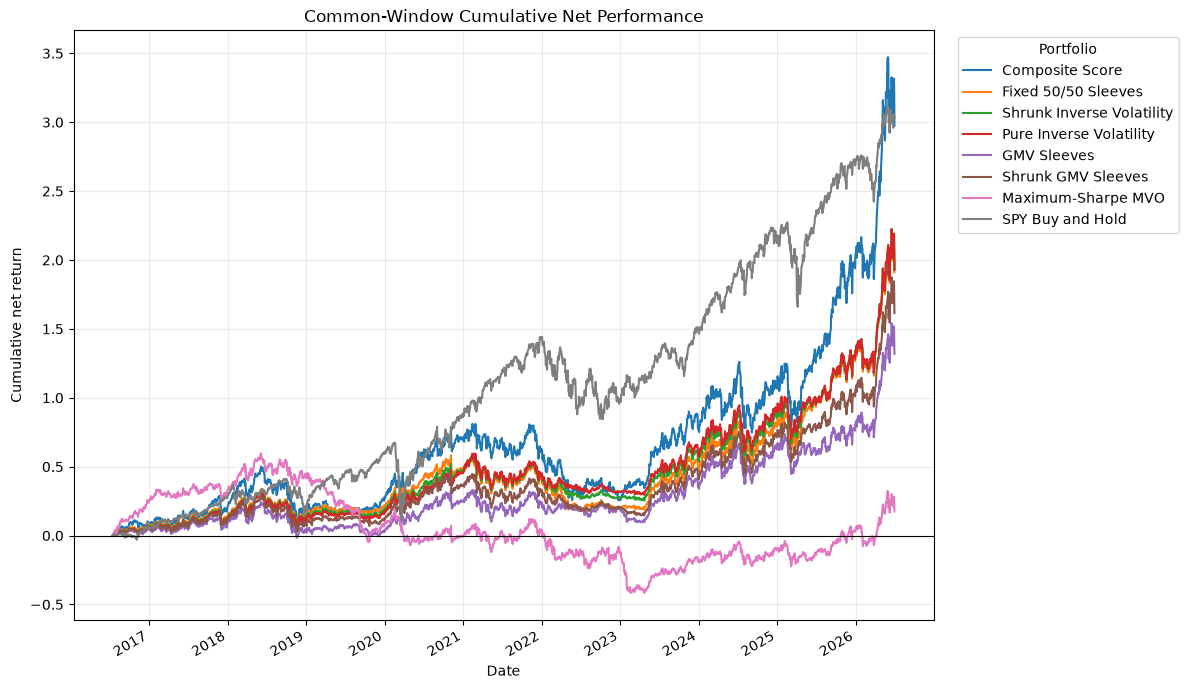

In [36]:
import matplotlib.pyplot as plt


mvo_common_cumulative_net = pd.DataFrame(
    {
        portfolio_name: (
            1.0 + daily.set_index("date")["net_return"]
        ).cumprod() - 1.0
        for portfolio_name, daily
        in mvo_common_window_daily.items()
    }
)

ax = mvo_common_cumulative_net.plot(
    figsize=(12, 7),
    linewidth=1.5,
)

ax.set_title(
    "Common-Window Cumulative Net Performance"
)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative net return")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.grid(alpha=0.25)
ax.legend(
    title="Portfolio",
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
)

plt.tight_layout()
plt.show()

### 2.4 Common-window findings

Restricting all portfolios to the maximum-Sharpe MVO live period does not change the main conclusions.

- **SPY is the strongest overall benchmark.** It produces the highest net annualised return (15.05%) and net Sharpe ratio (0.871), although its maximum drawdown is relatively severe (−33.72%).
- **The composite portfolio is the strongest active strategy by return.** Its net annualised return of 14.89% is close to SPY's, while its maximum drawdown is slightly smaller at −30.63%. However, its higher volatility and transaction costs reduce its net Sharpe ratio to 0.751.
- **Inverse-volatility allocation provides the best downside control.** Pure inverse volatility achieves the highest net Sharpe among the sleeve-allocation portfolios (0.738) and the smallest maximum drawdown in the comparison (−19.57%). Shrinkage produces very similar returns with slightly lower turnover and gross exposure, but does not materially improve risk-adjusted performance.
- **GMV optimisation is not beneficial.** The raw GMV portfolio underperforms the simpler sleeve allocations, while shrinkage recovers part—but not all—of the lost performance. This is consistent with covariance-estimation error making unconstrained optimisation unstable.
- **Maximum-Sharpe MVO fails decisively.** Despite average gross exposure of 1.90, it earns only 4.88% gross and 1.63% net per year, with a net Sharpe ratio of 0.182 and a −63.47% maximum drawdown. Its high turnover and transaction costs worsen the outcome, but the weak gross performance shows that trading costs are not the primary cause.
- **Simple portfolio rules remain more robust.** Composite scoring and inverse-volatility sleeve allocation both outperform the GMV and maximum-Sharpe optimisers, suggesting that estimation error and unstable expected-return forecasts outweigh the theoretical advantages of unconstrained MVO in this two-sleeve setting.

Overall, the comparison provides no evidence for promoting the raw maximum-Sharpe MVO portfolio. Its value is instead diagnostic: it demonstrates how sensitive mean–variance optimisation can be to noisy expected-return estimates, covariance estimates, leverage, and portfolio turnover.

### 2.5 Maximum-Sharpe MVO diagnosis

The common-window comparison shows that maximum-Sharpe MVO fails even before transaction costs. The following analysis tests the underlying mechanism directly: whether rolling expected-return differences predict subsequent sleeve performance, whether concentrated allocations select the better-performing sleeve, and how boundary solutions affect turnover.

For each allocation date, realised sleeve returns are measured from that date up to—but excluding—the next rebalance date. These forward returns are strictly out of sample relative to the estimates used by the optimiser.

In [37]:
mvo_diagnostic_allocations = mvo_allocations.copy()

diagnostic_period_end = mvo_diagnostic_allocations["date"].shift(-1).copy()

diagnostic_period_end.iloc[-1] = sleeve_return_frame.index.max() + pd.Timedelta(days=1)

mvo_diagnostic_allocations["period_end"] = diagnostic_period_end

forward_period_records = []

for allocation in mvo_diagnostic_allocations.itertuples(index=False):
    period_returns = sleeve_return_frame.loc[
        (sleeve_return_frame.index >= allocation.date)
        & (sleeve_return_frame.index < allocation.period_end),
        MVO_SLEEVES,
    ].dropna(how="any")

    if period_returns.empty:
        raise ValueError(f"No forward sleeve returns for " f"{allocation.date.date()}.")

    allocation_weights = pd.Series(
        {
            MOMENTUM_SLEEVE: allocation.momentum_weight,
            VOLATILITY_SLEEVE: (allocation.realised_volatility_weight),
        }
    )

    mvo_period_daily = period_returns.mul(
        allocation_weights,
        axis="columns",
    ).sum(axis=1)

    equal_weight_period_daily = period_returns.mean(axis=1)

    forward_period_records.append(
        {
            "date": allocation.date,
            "forward_observations": len(period_returns),
            "momentum_realised_return": (
                (1.0 + period_returns[MOMENTUM_SLEEVE]).prod() - 1.0
            ),
            "realised_volatility_realised_return": (
                (1.0 + period_returns[VOLATILITY_SLEEVE]).prod() - 1.0
            ),
            "mvo_period_return": ((1.0 + mvo_period_daily).prod() - 1.0),
            "equal_weight_period_return": (
                (1.0 + equal_weight_period_daily).prod() - 1.0
            ),
        }
    )

mvo_forward_diagnostics = mvo_diagnostic_allocations.merge(
    pd.DataFrame(forward_period_records),
    on="date",
    how="inner",
    validate="one_to_one",
)

mvo_forward_diagnostics["estimated_return_spread"] = (
    mvo_forward_diagnostics["momentum_estimated_return"]
    - mvo_forward_diagnostics["realised_volatility_estimated_return"]
)

mvo_forward_diagnostics["realised_return_spread"] = (
    mvo_forward_diagnostics["momentum_realised_return"]
    - mvo_forward_diagnostics["realised_volatility_realised_return"]
)

mvo_forward_diagnostics["allocation_spread"] = (
    mvo_forward_diagnostics["momentum_weight"]
    - mvo_forward_diagnostics["realised_volatility_weight"]
)

mvo_forward_diagnostics["mvo_minus_equal_return"] = (
    mvo_forward_diagnostics["mvo_period_return"]
    - mvo_forward_diagnostics["equal_weight_period_return"]
)

estimated_non_tie = mvo_forward_diagnostics["estimated_return_spread"].abs() > 1e-12

realised_non_tie = mvo_forward_diagnostics["realised_return_spread"].abs() > 1e-12

allocation_non_tie = mvo_forward_diagnostics["allocation_spread"].abs() > 1e-12

mvo_forward_diagnostics["return_rank_hit"] = np.where(
    estimated_non_tie & realised_non_tie,
    (
        mvo_forward_diagnostics["estimated_return_spread"]
        * mvo_forward_diagnostics["realised_return_spread"]
        > 0.0
    ),
    np.nan,
)

mvo_forward_diagnostics["allocated_sleeve_won"] = np.where(
    allocation_non_tie & realised_non_tie,
    (
        mvo_forward_diagnostics["allocation_spread"]
        * mvo_forward_diagnostics["realised_return_spread"]
        > 0.0
    ),
    np.nan,
)

mvo_forward_diagnostics["is_boundary"] = (
    mvo_forward_diagnostics["solution_type"] != "interior tangency"
)

mvo_rebalance_trading = mvo_live_backtest.loc[
    mvo_live_backtest["is_rebalance"],
    [
        "date",
        "turnover",
        "transaction_cost",
    ],
].copy()

mvo_forward_diagnostics = mvo_forward_diagnostics.merge(
    mvo_rebalance_trading,
    on="date",
    how="left",
    validate="one_to_one",
)

if mvo_forward_diagnostics[["turnover", "transaction_cost"]].isna().any().any():
    raise ValueError("Missing MVO rebalance trading diagnostics.")

display(mvo_forward_diagnostics.head())

,date,estimation_start,estimation_end,observations,momentum_weight,realised_volatility_weight,unconstrained_momentum_weight,solution_type,momentum_estimated_return,realised_volatility_estimated_return,...,equal_weight_period_return,estimated_return_spread,realised_return_spread,allocation_spread,mvo_minus_equal_return,return_rank_hit,allocated_sleeve_won,is_boundary,turnover,transaction_cost
0,2016-07-14,2016-01-07,2016-07-13,130,0.0,1.0,0.698770,realised-volatility boundary,-0.072756,-0.021521,...,-0.001303,-0.051235,-0.001166,-1.0,0.000502,1.0,1.0,True,2.000000,0.002000
1,2016-07-21,2016-01-07,2016-07-20,135,0.0,1.0,0.703870,realised-volatility boundary,-0.073681,-0.021641,...,0.025029,-0.052040,-0.040918,-1.0,0.020557,1.0,1.0,True,0.225809,0.000226
2,2016-07-28,2016-01-07,2016-07-27,140,0.0,1.0,1.819781,realised-volatility boundary,-0.062479,0.060030,...,-0.001737,-0.122509,0.005211,-1.0,-0.002714,0.0,0.0,True,0.380723,0.000381
3,2016-08-04,2016-01-07,2016-08-03,145,0.0,1.0,1.534226,realised-volatility boundary,-0.058862,0.050569,...,0.003037,-0.109431,-0.032184,-1.0,0.015921,1.0,1.0,True,0.223037,0.000223
4,2016-08-11,2016-01-07,2016-08-10,150,0.0,1.0,2.006680,realised-volatility boundary,-0.078877,0.081078,...,0.007314,-0.159955,-0.037756,-1.0,0.018964,1.0,1.0,True,0.228154,0.000228


In [38]:
diagnostic_observations = mvo_forward_diagnostics["forward_observations"].sum()

mvo_diagnostic_total_return = (
    1.0 + mvo_forward_diagnostics["mvo_period_return"]
).prod() - 1.0

equal_weight_diagnostic_total_return = (
    1.0 + mvo_forward_diagnostics["equal_weight_period_return"]
).prod() - 1.0

mvo_diagnostic_annualised_return = (1.0 + mvo_diagnostic_total_return) ** (
    252.0 / diagnostic_observations
) - 1.0

equal_weight_diagnostic_annualised_return = (
    1.0 + equal_weight_diagnostic_total_return
) ** (252.0 / diagnostic_observations) - 1.0

mvo_forecast_diagnostics = pd.Series(
    {
        "allocations": len(mvo_forward_diagnostics),
        "boundary_solution_fraction": (mvo_forward_diagnostics["is_boundary"].mean()),
        "estimated_vs_realised_spread_pearson": (
            mvo_forward_diagnostics["estimated_return_spread"].corr(
                mvo_forward_diagnostics["realised_return_spread"]
            )
        ),
        "estimated_vs_realised_spread_spearman": (
            mvo_forward_diagnostics["estimated_return_spread"].corr(
                mvo_forward_diagnostics["realised_return_spread"],
                method="spearman",
            )
        ),
        "return_ranking_hit_rate": (mvo_forward_diagnostics["return_rank_hit"].mean()),
        "higher_weight_sleeve_win_rate": (
            mvo_forward_diagnostics["allocated_sleeve_won"].mean()
        ),
        "positive_mvo_minus_equal_fraction": (
            (mvo_forward_diagnostics["mvo_minus_equal_return"] > 0.0).mean()
        ),
        "mean_mvo_minus_equal_bps_per_period": (
            mvo_forward_diagnostics["mvo_minus_equal_return"].mean() * 10_000
        ),
        "diagnostic_mvo_annualised_return": (mvo_diagnostic_annualised_return),
        "diagnostic_equal_weight_annualised_return": (
            equal_weight_diagnostic_annualised_return
        ),
        "average_boundary_turnover": (
            mvo_forward_diagnostics.loc[
                mvo_forward_diagnostics["is_boundary"],
                "turnover",
            ].mean()
        ),
        "average_interior_turnover": (
            mvo_forward_diagnostics.loc[
                ~mvo_forward_diagnostics["is_boundary"],
                "turnover",
            ].mean()
        ),
    },
    name="value",
)

solution_type_diagnostics = mvo_forward_diagnostics.groupby(
    "solution_type",
    sort=False,
).agg(
    allocations=("date", "size"),
    average_momentum_weight=(
        "momentum_weight",
        "mean",
    ),
    average_estimated_return_spread=(
        "estimated_return_spread",
        "mean",
    ),
    average_realised_return_spread=(
        "realised_return_spread",
        "mean",
    ),
    return_ranking_hit_rate=(
        "return_rank_hit",
        "mean",
    ),
    allocated_sleeve_win_rate=(
        "allocated_sleeve_won",
        "mean",
    ),
    mean_mvo_minus_equal_bps=(
        "mvo_minus_equal_return",
        lambda x: x.mean() * 10_000,
    ),
    average_turnover=("turnover", "mean"),
)

solution_type_diagnostics.insert(
    1,
    "allocation_fraction",
    (solution_type_diagnostics["allocations"] / len(mvo_forward_diagnostics)),
)

display(mvo_forecast_diagnostics.to_frame())
display(solution_type_diagnostics.round(4))

,value
allocations,501.000000
boundary_solution_fraction,0.616766
estimated_vs_realised_spread_pearson,-0.067785
estimated_vs_realised_spread_spearman,0.008421
return_ranking_hit_rate,0.483034
higher_weight_sleeve_win_rate,0.479042
positive_mvo_minus_equal_fraction,0.477046
mean_mvo_minus_equal_bps_per_period,-14.265116
diagnostic_mvo_annualised_return,0.047302
diagnostic_equal_weight_annualised_return,0.134486


,allocations,allocation_fraction,average_momentum_weight,average_estimated_return_spread,average_realised_return_spread,return_ranking_hit_rate,allocated_sleeve_win_rate,mean_mvo_minus_equal_bps,average_turnover
solution_type,,,,,,,,,
realised-volatility boundary,182,0.3633,0.0000,-0.2924,0.0011,0.5165,0.5110,-5.5703,0.5675
interior tangency,192,0.3832,0.3499,-0.2633,-0.0032,0.4479,0.4427,-5.6995,0.6576
momentum boundary,127,0.2535,1.0000,0.1926,-0.0082,0.4882,0.4882,-39.6750,0.6520


### 2.6 Diagnostic findings

The diagnosis identifies weak expected-return forecasts—not transaction costs or boundary turnover—as the primary cause of the maximum-Sharpe MVO's failure.

- Estimated and subsequently realised return spreads have essentially no relationship: Pearson correlation is −0.068 and Spearman correlation is 0.008.
- The forecast ranks the better-performing sleeve correctly only 48.3% of the time, while the sleeve receiving the higher weight wins only 47.9% of the time. Both are slightly worse than chance.
- MVO beats equal weighting in only 47.7% of rebalance periods and underperforms it by an average of 14.3 basis points per period. Its diagnostic annualised return is 4.73%, compared with 13.45% for equal weighting.
- Boundary solutions occur in 61.7% of allocations, confirming that noisy estimated returns frequently push the optimiser into concentrated positions.
- The most damaging case is the momentum boundary. Although the optimiser forecasts a large momentum advantage, momentum subsequently underperforms on average, producing an MVO shortfall of 39.7 basis points per period.
- Boundary turnover is not unusually high: it is slightly lower than turnover for interior solutions. Therefore, concentration and turnover amplify the problem, but the fundamental failure is the absence of out-of-sample predictive information in the expected-return spread.

Overall, the optimiser responds strongly to return estimates that do not reliably predict subsequent sleeve rankings. Maximum-Sharpe optimisation therefore converts forecast noise into concentrated and unstable allocations rather than improving portfolio performance.

### 2.7 Shrink MVO allocations toward equal weighting

Because the estimated return spread has no demonstrated out-of-sample predictive power, extensive tuning of a shrinkage coefficient would be difficult to justify. Instead, a small pre-specified sensitivity test interpolates between equal weighting and the raw maximum-Sharpe allocation:

$$
w_{\lambda,t}
=
(1-\lambda)w_{\mathrm{equal}}
+
\lambda w_{\mathrm{MVO},t},
$$

where $\lambda=0$ gives fixed 50/50 allocation and $\lambda=1$ reproduces raw MVO. The intermediate values are diagnostic rather than optimised parameters.

In [39]:
MVO_INTENSITIES = [0.0, 0.25, 0.50, 0.75, 1.0]

raw_mvo_sleeve_allocations = (
    mvo_allocations.set_index("date")[
        [
            "momentum_weight",
            "realised_volatility_weight",
        ]
    ]
    .rename(
        columns={
            "momentum_weight": MOMENTUM_SLEEVE,
            "realised_volatility_weight": VOLATILITY_SLEEVE,
        }
    )
    .sort_index()
)

raw_mvo_sleeve_allocations.index = pd.to_datetime(
    raw_mvo_sleeve_allocations.index
)
raw_mvo_sleeve_allocations.index.name = "date"

mvo_allocation_dates = pd.DatetimeIndex(
    raw_mvo_sleeve_allocations.index
).sort_values()

mvo_input_sleeve_targets = {}

for sleeve_name in MVO_SLEEVES:
    targets = sleeve_targets[sleeve_name].copy()
    targets["date"] = pd.to_datetime(targets["date"])

    mvo_input_sleeve_targets[sleeve_name] = (
        targets.loc[
            targets["date"].isin(mvo_allocation_dates)
        ]
        .sort_values(["date", "ticker"])
        .reset_index(drop=True)
    )

    target_dates = pd.DatetimeIndex(
        mvo_input_sleeve_targets[sleeve_name]["date"].unique()
    ).sort_values()

    if not target_dates.equals(mvo_allocation_dates):
        raise ValueError(
            f"{sleeve_name} target dates do not match "
            "the MVO allocation dates."
        )

mvo_shrinkage_daily = {}
mvo_shrinkage_allocations = {}

for intensity in MVO_INTENSITIES:
    shrunk_allocations = (
        0.5
        + intensity
        * (raw_mvo_sleeve_allocations - 0.5)
    )

    if not np.allclose(
        shrunk_allocations.sum(axis=1),
        1.0,
    ):
        raise ValueError(
            f"Allocations do not sum to one for "
            f"intensity {intensity:.2f}."
        )

    shrunk_targets = (
        combine_dynamic_sleeve_target_weights(
            sleeve_targets=mvo_input_sleeve_targets,
            sleeve_allocations=shrunk_allocations,
        )
    )

    shrunk_daily, _ = run_target_weight_backtest(
        return_panel=return_panel,
        target_weights=shrunk_targets,
        return_column="forward_ret_1d",
        transaction_cost_bps=TRANSACTION_COST_BPS,
    )

    shrunk_daily["date"] = pd.to_datetime(
        shrunk_daily["date"]
    )

    shrunk_daily = (
        shrunk_daily.loc[
            shrunk_daily["date"].between(
                mvo_live_start,
                mvo_live_backtest["date"].max(),
            )
        ]
        .copy()
        .reset_index(drop=True)
    )

    mvo_shrinkage_allocations[intensity] = (
        shrunk_allocations
    )

    mvo_shrinkage_daily[intensity] = shrunk_daily

In [40]:
mvo_shrinkage_rows = []

for intensity in MVO_INTENSITIES:
    daily = mvo_shrinkage_daily[intensity]
    allocations = mvo_shrinkage_allocations[intensity]

    gross_summary = summarise_backtest(
        daily,
        return_column="gross_return",
    ).iloc[0]

    net_summary = summarise_backtest(
        daily,
        return_column="net_return",
    ).iloc[0]

    mvo_shrinkage_rows.append(
        {
            "mvo_intensity": intensity,
            "average_momentum_weight": (allocations[MOMENTUM_SLEEVE].mean()),
            "momentum_weight_std": (allocations[MOMENTUM_SLEEVE].std()),
            "gross_annualised_return": (gross_summary["annualised_return"]),
            "net_annualised_return": (net_summary["annualised_return"]),
            "net_annualised_volatility": (net_summary["annualised_volatility"]),
            "net_sharpe": net_summary["sharpe_ratio"],
            "net_max_drawdown": (net_summary["max_drawdown"]),
            "average_daily_turnover": (net_summary["average_daily_turnover"]),
            "average_rebalance_turnover": (net_summary["average_rebalance_turnover"]),
            "total_transaction_cost": (net_summary["total_transaction_cost"]),
        }
    )

mvo_shrinkage_summary = pd.DataFrame(mvo_shrinkage_rows).set_index("mvo_intensity")

equal_weight_return = mvo_shrinkage_summary.loc[
    0.0,
    "net_annualised_return",
]

equal_weight_sharpe = mvo_shrinkage_summary.loc[
    0.0,
    "net_sharpe",
]

mvo_shrinkage_summary["net_return_minus_50_50"] = (
    mvo_shrinkage_summary["net_annualised_return"] - equal_weight_return
)

mvo_shrinkage_summary["net_sharpe_minus_50_50"] = (
    mvo_shrinkage_summary["net_sharpe"] - equal_weight_sharpe
)

display(mvo_shrinkage_summary.round(4))

,average_momentum_weight,momentum_weight_std,gross_annualised_return,net_annualised_return,net_annualised_volatility,net_sharpe,net_max_drawdown,average_daily_turnover,average_rebalance_turnover,total_transaction_cost,net_return_minus_50_50,net_sharpe_minus_50_50
mvo_intensity,,,,,,,,,,,,
0.00,0.5000,0.0000,0.1382,0.1134,0.1707,0.7151,-0.2566,0.0873,0.4363,0.2186,0.0000,0.0000
0.25,0.4719,0.1028,0.1174,0.0911,0.1705,0.5969,-0.2995,0.0946,0.4730,0.2370,-0.0223,-0.1182
0.50,0.4438,0.2056,0.0956,0.0673,0.1766,0.4574,-0.4155,0.1038,0.5189,0.2600,-0.0461,-0.2577
0.75,0.4157,0.3084,0.0727,0.0424,0.1885,0.3149,-0.5348,0.1137,0.5684,0.2848,-0.0710,-0.4002
1.00,0.3876,0.4111,0.0488,0.0163,0.2053,0.1822,-0.6347,0.1247,0.6234,0.3123,-0.0971,-0.5329


### 2.8 Shrinkage findings

Shrinking the maximum-Sharpe MVO allocations toward equal weighting does not recover useful portfolio performance.

- Fixed 50/50 allocation produces the strongest result, with an 11.34% net annualised return, a 0.715 net Sharpe ratio, and a −25.66% maximum drawdown.
- Performance deteriorates steadily as MVO intensity increases. Even a 25% MVO tilt reduces the net annualised return by 2.23 percentage points and the net Sharpe ratio by 0.118.
- At full MVO intensity, the net annualised return falls to 1.63%, the Sharpe ratio to 0.182, and the maximum drawdown worsens to −63.47%.
- Gross returns also decline monotonically, confirming that transaction costs are not the primary cause. Higher MVO intensity additionally increases turnover and total transaction costs, further worsening net performance.
- The slight reduction in volatility at 25% intensity is economically insignificant and is accompanied by materially weaker return, Sharpe ratio, and drawdown.

These results are consistent with the forecast diagnosis: the optimiser's estimated return differences contain no reliable out-of-sample information. Shrinkage merely controls how much forecast noise enters the portfolio, so its best observed outcome is the limiting case in which the MVO signal is ignored entirely.

No shrinkage coefficient is selected or tuned. Fixed weighting and inverse-volatility allocation remain the preferred sleeve-allocation methods, while raw and shrunk maximum-Sharpe MVO are retained only as diagnostic experiments.

## 3. Portfolio optimisation conclusions

The experiments provide no evidence that formal mean–variance optimisation improves allocation between the momentum and realised-volatility sleeves.

### 3.1 Global minimum variance

Raw GMV produced economically plausible allocations, but its sensitivity to the rolling covariance estimate introduced weight variation without reducing realised portfolio risk. Shrinking the GMV weights toward equal allocation improved performance, but still did not outperform the simpler inverse-volatility methods.

This suggests that the time-varying sleeve-correlation estimate adds more estimation noise than useful diversification information in the current two-sleeve setting.

### 3.2 Maximum-Sharpe MVO

Maximum-Sharpe MVO performed substantially worse than every simpler active allocation:

- its net annualised return was 1.63%;
- its net Sharpe ratio was 0.182;
- its maximum drawdown reached −63.47%; and
- its cumulative transaction cost reached 31.23%.

Weak gross performance shows that transaction costs were not the fundamental cause.

The forecast diagnosis explains the failure. Estimated and subsequently realised sleeve-return spreads were effectively unrelated, the predicted sleeve ranking was correct only 48.3% of the time, and boundary allocations occurred in 61.7% of rebalance decisions. The optimiser therefore converted noisy historical return estimates into concentrated allocations without reliable timing information.

The pre-specified shrinkage experiment confirmed this interpretation. Performance deteriorated almost monotonically as MVO intensity increased from zero to one. Even a 25% MVO tilt materially reduced return and Sharpe relative to fixed 50/50 allocation. No shrinkage coefficient is selected or tuned.

### 3.3 Portfolio selection

Over the common MVO evaluation period:

- **Composite Score** was the strongest active construction by return, earning 14.89% net annually with a 0.751 Sharpe ratio.
- **Pure Inverse Volatility** provided the strongest downside control among the active sleeve allocations, with a 0.738 net Sharpe ratio and a −19.57% maximum drawdown.
- **Fixed 50/50 Sleeves** remained the simplest robust allocation benchmark.
- **SPY Buy and Hold** produced the highest overall return and Sharpe ratio, although with a larger drawdown than the risk-balanced sleeve portfolios.
- **GMV, shrunk GMV, and maximum-Sharpe MVO** are retained as documented diagnostic experiments rather than candidate implementations.

The central lesson is that optimisation complexity is useful only when its estimated inputs contain stable out-of-sample information. In this experiment, simple diversification and volatility-based allocation were more robust than direct covariance or expected-return optimisation.

The next notebook evaluates whether the shortlisted portfolios remain viable under alternative transaction costs, rebalance frequencies, subperiods, and implementation constraints.

## 4. Export results

The following cells preserve the principal outputs from the optimisation experiments:

- aligned daily results for GMV, shrunk GMV, and maximum-Sharpe MVO;
- the final common-window strategy comparison;
- the MVO forecast and solution-type diagnostics; and
- the pre-specified MVO shrinkage-sensitivity results.

The benchmark portfolios required by the next notebook remain available from the exports produced by Notebook 04.

In [ ]:
OPTIMISATION_PORTFOLIOS_TO_EXPORT = [
    "GMV Sleeves",
    "Shrunk GMV Sleeves",
    "Maximum-Sharpe MVO",
]

OPTIMISATION_DAILY_RESULT_COLUMNS = [
    "date",
    "gross_return",
    "net_return",
    "turnover",
    "transaction_cost",
    "is_rebalance",
    "missing_return_weight",
    "gross_exposure",
    "net_exposure",
]

optimisation_daily_parts = []

for portfolio_name in OPTIMISATION_PORTFOLIOS_TO_EXPORT:
    daily = mvo_common_window_daily[portfolio_name].copy()

    missing_columns = set(OPTIMISATION_DAILY_RESULT_COLUMNS) - set(daily.columns)

    if missing_columns:
        raise ValueError(
            f"{portfolio_name} is missing export columns: " f"{sorted(missing_columns)}"
        )

    daily = daily[OPTIMISATION_DAILY_RESULT_COLUMNS].copy()

    daily["date"] = pd.to_datetime(daily["date"])

    daily = (
        daily.sort_values("date")
        .reset_index(drop=True)
        .assign(portfolio=portfolio_name)
    )

    if daily["date"].duplicated().any():
        raise ValueError(f"{portfolio_name} contains duplicate dates.")

    portfolio_dates = pd.DatetimeIndex(daily["date"])

    if not portfolio_dates.equals(reference_dates):
        raise ValueError(
            f"{portfolio_name} is not aligned with " "the common evaluation dates."
        )

    optimisation_daily_parts.append(daily)

portfolio_optimisation_daily = pd.concat(
    optimisation_daily_parts,
    ignore_index=True,
)[
    [
        "date",
        "portfolio",
        *OPTIMISATION_DAILY_RESULT_COLUMNS[1:],
    ]
]

if portfolio_optimisation_daily.duplicated(["portfolio", "date"]).any():
    raise ValueError("Duplicate portfolio-date observations found.")

display(portfolio_optimisation_daily.head())

,date,portfolio,gross_return,net_return,turnover,transaction_cost,is_rebalance,missing_return_weight,gross_exposure,net_exposure
0,2016-07-14,GMV Sleeves,0.000760,-0.000569,1.329645,0.00133,True,0.0,1.329645,0.000000
1,2016-07-15,GMV Sleeves,0.005129,0.005129,0.000000,0.00000,False,0.0,1.325735,0.000760
2,2016-07-18,GMV Sleeves,-0.003609,-0.003609,0.000000,0.00000,False,0.0,1.326925,0.005859
3,2016-07-19,GMV Sleeves,0.004799,0.004799,0.000000,0.00000,False,0.0,1.327527,0.002257
4,2016-07-20,GMV Sleeves,-0.008491,-0.008491,0.000000,0.00000,False,0.0,1.329365,0.007023


In [42]:
portfolio_optimisation_summary = mvo_common_window_summary.rename_axis(
    "portfolio"
).reset_index()

mvo_forecast_diagnostics_export = mvo_forecast_diagnostics.rename_axis(
    "metric"
).reset_index(name="value")

mvo_solution_type_diagnostics_export = solution_type_diagnostics.rename_axis(
    "solution_type"
).reset_index()

mvo_shrinkage_sensitivity_export = mvo_shrinkage_summary.rename_axis(
    "mvo_intensity"
).reset_index()

if portfolio_optimisation_summary["portfolio"].duplicated().any():
    raise ValueError("Duplicate portfolios found in the summary.")

if mvo_forecast_diagnostics_export["metric"].duplicated().any():
    raise ValueError("Duplicate MVO diagnostic metrics found.")

if mvo_solution_type_diagnostics_export["solution_type"].duplicated().any():
    raise ValueError("Duplicate MVO solution types found.")

if not np.allclose(
    mvo_shrinkage_sensitivity_export["mvo_intensity"].to_numpy(),
    MVO_INTENSITIES,
):
    raise ValueError("Unexpected MVO shrinkage intensities.")

display(portfolio_optimisation_summary.round(4))
display(mvo_forecast_diagnostics_export.round(4))
display(mvo_solution_type_diagnostics_export.round(4))
display(mvo_shrinkage_sensitivity_export.round(4))

,portfolio,start_date,end_date,observations,gross_annualised_return,net_annualised_return,net_annualised_volatility,gross_sharpe,net_sharpe,net_max_drawdown,average_daily_turnover,average_rebalance_turnover,total_transaction_cost,average_gross_exposure,cumulative_net_return
0,Composite Score,2016-07-14,2026-07-01,2505,0.1794,0.1489,0.2161,0.8723,0.7511,-0.3063,0.1039,0.5194,0.2602,2.0006,2.9745
1,Fixed 50/50 Sleeves,2016-07-14,2026-07-01,2505,0.1382,0.1135,0.1707,0.8441,0.7156,-0.2566,0.0869,0.4345,0.2177,1.5519,1.9118
2,Shrunk Inverse Volatility,2016-07-14,2026-07-01,2505,0.1397,0.1142,0.1662,0.8709,0.7345,-0.2103,0.0898,0.4491,0.2250,1.5926,1.9309
3,Pure Inverse Volatility,2016-07-14,2026-07-01,2505,0.1404,0.1142,0.1650,0.8792,0.7381,-0.1957,0.0922,0.4611,0.2310,1.6198,1.9292
4,GMV Sleeves,2016-07-14,2026-07-01,2505,0.1148,0.0883,0.1701,0.7248,0.5827,-0.2077,0.0958,0.4791,0.2400,1.6946,1.3180
5,Shrunk GMV Sleeves,2016-07-14,2026-07-01,2505,0.1271,0.1015,0.1673,0.7994,0.6620,-0.2137,0.0911,0.4556,0.2282,1.6232,1.6150
6,Maximum-Sharpe MVO,2016-07-14,2026-07-01,2505,0.0488,0.0163,0.2053,0.3354,0.1822,-0.6347,0.1247,0.6234,0.3123,1.9006,0.1748
7,SPY Buy and Hold,2016-07-14,2026-07-01,2505,0.1505,0.1505,0.1795,0.8713,0.8713,-0.3372,0.0000,NaN,0.0000,1.0000,3.0290


,metric,value
0,allocations,501.0000
1,boundary_solution_fraction,0.6168
2,estimated_vs_realised_spread_pearson,-0.0678
3,estimated_vs_realised_spread_spearman,0.0084
4,return_ranking_hit_rate,0.4830
5,higher_weight_sleeve_win_rate,0.4790
6,positive_mvo_minus_equal_fraction,0.4770
7,mean_mvo_minus_equal_bps_per_period,-14.2651
8,diagnostic_mvo_annualised_return,0.0473
9,diagnostic_equal_weight_annualised_return,0.1345


,solution_type,allocations,allocation_fraction,average_momentum_weight,average_estimated_return_spread,average_realised_return_spread,return_ranking_hit_rate,allocated_sleeve_win_rate,mean_mvo_minus_equal_bps,average_turnover
0,realised-volatility boundary,182,0.3633,0.0000,-0.2924,0.0011,0.5165,0.5110,-5.5703,0.5675
1,interior tangency,192,0.3832,0.3499,-0.2633,-0.0032,0.4479,0.4427,-5.6995,0.6576
2,momentum boundary,127,0.2535,1.0000,0.1926,-0.0082,0.4882,0.4882,-39.6750,0.6520


,mvo_intensity,average_momentum_weight,momentum_weight_std,gross_annualised_return,net_annualised_return,net_annualised_volatility,net_sharpe,net_max_drawdown,average_daily_turnover,average_rebalance_turnover,total_transaction_cost,net_return_minus_50_50,net_sharpe_minus_50_50
0,0.00,0.5000,0.0000,0.1382,0.1134,0.1707,0.7151,-0.2566,0.0873,0.4363,0.2186,0.0000,0.0000
1,0.25,0.4719,0.1028,0.1174,0.0911,0.1705,0.5969,-0.2995,0.0946,0.4730,0.2370,-0.0223,-0.1182
2,0.50,0.4438,0.2056,0.0956,0.0673,0.1766,0.4574,-0.4155,0.1038,0.5189,0.2600,-0.0461,-0.2577
3,0.75,0.4157,0.3084,0.0727,0.0424,0.1885,0.3149,-0.5348,0.1137,0.5684,0.2848,-0.0710,-0.4002
4,1.00,0.3876,0.4111,0.0488,0.0163,0.2053,0.1822,-0.6347,0.1247,0.6234,0.3123,-0.0971,-0.5329


In [43]:
portfolio_optimisation_exports = {
    "portfolio_optimisation_daily.parquet": (portfolio_optimisation_daily),
    "portfolio_optimisation_summary.parquet": (portfolio_optimisation_summary),
    "mvo_forecast_diagnostics.parquet": (mvo_forecast_diagnostics_export),
    "mvo_solution_type_diagnostics.parquet": (mvo_solution_type_diagnostics_export),
    "mvo_shrinkage_sensitivity.parquet": (mvo_shrinkage_sensitivity_export),
}

export_manifest_rows = []

for filename, dataframe in portfolio_optimisation_exports.items():
    export_path = PROCESSED_DATA_DIR / filename

    dataframe.to_parquet(
        export_path,
        index=False,
    )

    saved_data = load_parquet(export_path)

    if saved_data.shape != dataframe.shape:
        raise ValueError(f"Read-back shape mismatch for {filename}.")

    if saved_data.columns.tolist() != dataframe.columns.tolist():
        raise ValueError(f"Read-back column mismatch for {filename}.")

    export_manifest_rows.append(
        {
            "file": filename,
            "rows": len(dataframe),
            "columns": dataframe.shape[1],
        }
    )

portfolio_optimisation_export_manifest = pd.DataFrame(export_manifest_rows)

display(portfolio_optimisation_export_manifest)

print(
    "Exported all Notebook 05 results to:",
    PROCESSED_DATA_DIR,
)

,file,rows,columns
0,portfolio_optimisation_daily.parquet,7515,10
1,portfolio_optimisation_summary.parquet,8,15
2,mvo_forecast_diagnostics.parquet,12,2
3,mvo_solution_type_diagnostics.parquet,3,10
4,mvo_shrinkage_sensitivity.parquet,5,13


Exported all Notebook 05 results to: data/processed
